In [1]:
# Cell 0: Imports and database connection

import os
import json
import sqlite3
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Project Paths ──────────────────────────────────────
BASE        = "D:/Projects/Harsh_Mini_Project/medical_xray_project"
PLOTS       = f"{BASE}/outputs/plots"
RESULTS     = f"{BASE}/outputs/results"
DB_PATH     = f"{BASE}/database/xray_metadata.db"

# ── Connect to database ────────────────────────────────
conn   = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

print("=" * 50)
print("   CELL 0: DATABASE CONNECTION")
print("=" * 50)
print(f"✅ Connected to database")
print(f"   Path : {DB_PATH}")
print()

# Check if DB file exists
if os.path.exists(DB_PATH):
    size_kb = os.path.getsize(DB_PATH) / 1024
    print(f"✅ DB file size : {size_kb:.1f} KB")

# Check existing tables
cursor.execute(
    "SELECT name FROM sqlite_master "
    "WHERE type='table'")
existing_tables = cursor.fetchall()
if existing_tables:
    print(f"   Existing tables: "
          f"{[t[0] for t in existing_tables]}")
else:
    print(f"   No existing tables yet")

print()
print(f"✅ SQLite version : "
      f"{sqlite3.sqlite_version}")
print("=" * 50)
print("✅ Cell 0 complete - Ready to proceed")

   CELL 0: DATABASE CONNECTION
✅ Connected to database
   Path : D:/Projects/Harsh_Mini_Project/medical_xray_project/database/xray_metadata.db

✅ DB file size : 12.0 KB
   Existing tables: ['sqlite_sequence']

✅ SQLite version : 3.45.1
✅ Cell 0 complete - Ready to proceed


In [2]:
# Cell 1: Load all CSV files

print("=" * 50)
print("   CELL 1: LOADING ALL CSV FILES")
print("=" * 50)

# ── Load all CSVs ──────────────────────────────────────
metadata_df = pd.read_csv(
    f"{RESULTS}/processed_metadata.csv",
    encoding='utf-8')

train_df    = pd.read_csv(
    f"{RESULTS}/train.csv",
    encoding='utf-8')

val_df      = pd.read_csv(
    f"{RESULTS}/val.csv",
    encoding='utf-8')

test_df     = pd.read_csv(
    f"{RESULTS}/test.csv",
    encoding='utf-8')

pred_df     = pd.read_csv(
    f"{RESULTS}/test_predictions.csv",
    encoding='utf-8')

bias_gender_df  = pd.read_csv(
    f"{RESULTS}/bias_gender.csv",
    encoding='utf-8')

bias_age_df     = pd.read_csv(
    f"{RESULTS}/bias_age_group.csv",
    encoding='utf-8')

bias_combined_df = pd.read_csv(
    f"{RESULTS}/bias_combined.csv",
    encoding='utf-8')

# ── Load test metrics ──────────────────────────────────
with open(f"{RESULTS}/test_metrics.json",
          'r', encoding='utf-8') as f:
    test_metrics = json.load(f)

# ── Print summary ──────────────────────────────────────
dfs = {
    'metadata_df'     : metadata_df,
    'train_df'        : train_df,
    'val_df'          : val_df,
    'test_df'         : test_df,
    'pred_df'         : pred_df,
    'bias_gender_df'  : bias_gender_df,
    'bias_age_df'     : bias_age_df,
    'bias_combined_df': bias_combined_df,
}

for name, df in dfs.items():
    print(f"✅ {name:<20} : "
          f"{len(df):>6,} rows × "
          f"{len(df.columns)} cols")

print()
print(f"✅ test_metrics loaded:")
for k, v in test_metrics.items():
    print(f"   {k:<16} : {v:.4f}")

print("=" * 50)
print("✅ Cell 1 complete")

   CELL 1: LOADING ALL CSV FILES
✅ metadata_df          :  5,840 rows × 9 cols
✅ train_df             :  4,087 rows × 9 cols
✅ val_df               :    877 rows × 9 cols
✅ test_df              :    876 rows × 9 cols
✅ pred_df              :    876 rows × 11 cols
✅ bias_gender_df       :      2 rows × 7 cols
✅ bias_age_df          :      3 rows × 7 cols
✅ bias_combined_df     :      6 rows × 8 cols

✅ test_metrics loaded:
   accuracy         : 0.9737
   precision        : 0.9889
   recall           : 0.9750
   f1_score         : 0.9819
   test_auc         : 0.9966
   TN               : 229.0000
   FP               : 7.0000
   FN               : 16.0000
   TP               : 624.0000
   total_samples    : 876.0000
   correct          : 853.0000
   wrong            : 23.0000
✅ Cell 1 complete


In [3]:
# Cell 2: Drop and create all 5 SQL tables

print("=" * 50)
print("   CELL 2: CREATING SQL TABLES")
print("=" * 50)

# ── Drop all existing tables first ─────────────────────
tables_to_drop = ['patients', 'predictions',
                  'bias_gender', 'bias_age_group',
                  'bias_combined']

for table in tables_to_drop:
    cursor.execute(
        f"DROP TABLE IF EXISTS {table}")
conn.commit()
print(f"✅ All old tables dropped")
print()

# ── Table 1: patients ──────────────────────────────────
cursor.execute("""
    CREATE TABLE IF NOT EXISTS patients (
        id            INTEGER PRIMARY KEY
                      AUTOINCREMENT,
        image_index   TEXT,
        patient_id    INTEGER,
        age           REAL,
        gender        TEXT,
        age_group     TEXT,
        view_position TEXT,
        label         INTEGER,
        label_name    TEXT,
        split         TEXT
    )
""")
print(f"✅ Table 1 created : patients")

# ── Table 2: predictions ───────────────────────────────
cursor.execute("""
    CREATE TABLE IF NOT EXISTS predictions (
        id            INTEGER PRIMARY KEY
                      AUTOINCREMENT,
        image_index   TEXT,
        patient_id    INTEGER,
        age           REAL,
        gender        TEXT,
        age_group     TEXT,
        true_label    INTEGER,
        predicted     INTEGER,
        confidence    REAL,
        correct       INTEGER,
        label_name    TEXT
    )
""")
print(f"✅ Table 2 created : predictions")

# ── Table 3: bias_gender ───────────────────────────────
cursor.execute("""
    CREATE TABLE IF NOT EXISTS bias_gender (
        id        INTEGER PRIMARY KEY
                  AUTOINCREMENT,
        gender    TEXT,
        samples   INTEGER,
        accuracy  REAL,
        precision REAL,
        recall    REAL,
        f1_score  REAL,
        auc       REAL
    )
""")
print(f"✅ Table 3 created : bias_gender")

# ── Table 4: bias_age_group ────────────────────────────
cursor.execute("""
    CREATE TABLE IF NOT EXISTS bias_age_group (
        id        INTEGER PRIMARY KEY
                  AUTOINCREMENT,
        age_group TEXT,
        samples   INTEGER,
        accuracy  REAL,
        precision REAL,
        recall    REAL,
        f1_score  REAL,
        auc       REAL
    )
""")
print(f"✅ Table 4 created : bias_age_group")

# ── Table 5: bias_combined ─────────────────────────────
cursor.execute("""
    CREATE TABLE IF NOT EXISTS bias_combined (
        id        INTEGER PRIMARY KEY
                  AUTOINCREMENT,
        gender    TEXT,
        age_group TEXT,
        samples   INTEGER,
        accuracy  REAL,
        precision REAL,
        recall    REAL,
        f1_score  REAL,
        auc       REAL
    )
""")
print(f"✅ Table 5 created : bias_combined")

conn.commit()
print()

# ── Verify all tables created ──────────────────────────
cursor.execute(
    "SELECT name FROM sqlite_master "
    "WHERE type='table' "
    "ORDER BY name")
tables = cursor.fetchall()
print(f"   Tables in database:")
for t in tables:
    print(f"   ✅ {t[0]}")

print("=" * 50)
print("✅ Cell 2 complete")

   CELL 2: CREATING SQL TABLES
✅ All old tables dropped

✅ Table 1 created : patients
✅ Table 2 created : predictions
✅ Table 3 created : bias_gender
✅ Table 4 created : bias_age_group
✅ Table 5 created : bias_combined

   Tables in database:
   ✅ bias_age_group
   ✅ bias_combined
   ✅ bias_gender
   ✅ patients
   ✅ predictions
   ✅ sqlite_sequence
✅ Cell 2 complete


In [4]:
# Cell 3: Insert data into all 5 tables

print("=" * 50)
print("   CELL 3: INSERTING DATA INTO TABLES")
print("=" * 50)

# ── Table 1: patients ──────────────────────────────────
# Verify columns match exactly
print(f"   metadata_df columns:")
print(f"   {metadata_df.columns.tolist()}")
print()

# Rename columns to match SQL table exactly
patients_df = metadata_df[[
    'image_index', 'patient_id', 'age',
    'gender', 'age_group', 'view_position',
    'label', 'label_name', 'split'
]].copy()

patients_df.to_sql(
    'patients', conn,
    if_exists='append',
    index=False
)
conn.commit()
count = cursor.execute(
    "SELECT COUNT(*) FROM patients"
).fetchone()[0]
print(f"✅ patients      : {count:,} rows inserted")

# ── Table 2: predictions ───────────────────────────────
print(f"   pred_df columns:")
print(f"   {pred_df.columns.tolist()}")
print()

predictions_insert = pred_df[[
    'image_index', 'patient_id', 'age',
    'gender', 'age_group', 'true_label',
    'predicted', 'confidence', 'correct',
    'label_name'
]].copy()

predictions_insert.to_sql(
    'predictions', conn,
    if_exists='append',
    index=False
)
conn.commit()
count = cursor.execute(
    "SELECT COUNT(*) FROM predictions"
).fetchone()[0]
print(f"✅ predictions   : {count:,} rows inserted")

# ── Table 3: bias_gender ───────────────────────────────
print(f"   bias_gender_df columns:")
print(f"   {bias_gender_df.columns.tolist()}")

bias_gender_df.to_sql(
    'bias_gender', conn,
    if_exists='append',
    index=False
)
conn.commit()
count = cursor.execute(
    "SELECT COUNT(*) FROM bias_gender"
).fetchone()[0]
print(f"✅ bias_gender   : {count:,} rows inserted")

# ── Table 4: bias_age_group ────────────────────────────
print(f"   bias_age_df columns:")
print(f"   {bias_age_df.columns.tolist()}")

bias_age_df.to_sql(
    'bias_age_group', conn,
    if_exists='append',
    index=False
)
conn.commit()
count = cursor.execute(
    "SELECT COUNT(*) FROM bias_age_group"
).fetchone()[0]
print(f"✅ bias_age_group: {count:,} rows inserted")

# ── Table 5: bias_combined ─────────────────────────────
print(f"   bias_combined_df columns:")
print(f"   {bias_combined_df.columns.tolist()}")

bias_combined_insert = bias_combined_df[[
    'gender', 'age_group', 'samples',
    'accuracy', 'precision', 'recall',
    'f1_score', 'auc'
]].copy()

bias_combined_insert.to_sql(
    'bias_combined', conn,
    if_exists='append',
    index=False
)
conn.commit()
count = cursor.execute(
    "SELECT COUNT(*) FROM bias_combined"
).fetchone()[0]
print(f"✅ bias_combined : {count:,} rows inserted")

print()
print("=" * 50)
print("✅ Cell 3 complete - All data inserted!")

   CELL 3: INSERTING DATA INTO TABLES
   metadata_df columns:
   ['image_index', 'label', 'label_name', 'patient_id', 'age', 'gender', 'view_position', 'age_group', 'split']

✅ patients      : 5,840 rows inserted
   pred_df columns:
   ['image_index', 'patient_id', 'age', 'gender', 'age_group', 'true_label', 'predicted', 'confidence', 'label_name', 'correct', 'predicted_name']

✅ predictions   : 876 rows inserted
   bias_gender_df columns:
   ['gender', 'samples', 'accuracy', 'precision', 'recall', 'f1_score', 'auc']
✅ bias_gender   : 2 rows inserted
   bias_age_df columns:
   ['age_group', 'samples', 'accuracy', 'precision', 'recall', 'f1_score', 'auc']
✅ bias_age_group: 3 rows inserted
   bias_combined_df columns:
   ['gender', 'age_group', 'samples', 'accuracy', 'precision', 'recall', 'f1_score', 'auc']
✅ bias_combined : 6 rows inserted

✅ Cell 3 complete - All data inserted!


In [5]:
# Cell 4: Verify row counts in all tables

print("=" * 50)
print("   CELL 4: VERIFYING ROW COUNTS")
print("=" * 50)

tables = ['patients', 'predictions',
          'bias_gender', 'bias_age_group',
          'bias_combined']

expected = {
    'patients'      : 5840,
    'predictions'   : 876,
    'bias_gender'   : 2,
    'bias_age_group': 3,
    'bias_combined' : 6,
}

all_ok = True
for table in tables:
    count    = cursor.execute(
        f"SELECT COUNT(*) FROM {table}"
    ).fetchone()[0]
    exp      = expected[table]
    status   = "✅" if count == exp else "⚠️"
    if count != exp:
        all_ok = False
    print(f"   {status} {table:<16} : "
          f"{count:>6,} rows "
          f"(expected {exp:,})")

print()

# ── Show sample rows from each table ──────────────────
print(f"   Sample from patients table:")
rows = cursor.execute("""
    SELECT image_index, age, gender,
           age_group, label_name, split
    FROM patients
    LIMIT 3
""").fetchall()
for r in rows:
    print(f"   {r}")

print()
print(f"   Sample from predictions table:")
rows = cursor.execute("""
    SELECT image_index, gender, age_group,
           true_label, predicted, correct
    FROM predictions
    LIMIT 3
""").fetchall()
for r in rows:
    print(f"   {r}")

print()
print(f"   Sample from bias_gender table:")
rows = cursor.execute("""
    SELECT * FROM bias_gender
""").fetchall()
for r in rows:
    print(f"   {r}")

print()
if all_ok:
    print(f"✅ All row counts verified!")
else:
    print(f"⚠️  Some counts don't match!")
print("=" * 50)
print("✅ Cell 4 complete")

   CELL 4: VERIFYING ROW COUNTS
   ✅ patients         :  5,840 rows (expected 5,840)
   ✅ predictions      :    876 rows (expected 876)
   ✅ bias_gender      :      2 rows (expected 2)
   ✅ bias_age_group   :      3 rows (expected 3)
   ✅ bias_combined    :      6 rows (expected 6)

   Sample from patients table:
   ('train_PNEUMONIA_person898_bacteria_2823.jpeg', 72.0, 'F', 'Old', 'PNEUMONIA', 'train')
   ('train_PNEUMONIA_person381_bacteria_1731.jpeg', 21.0, 'M', 'Young', 'PNEUMONIA', 'train')
   ('train_NORMAL_NORMAL2-IM-0936-0001.jpeg', 58.0, 'F', 'Middle', 'NORMAL', 'train')

   Sample from predictions table:
   ('train_PNEUMONIA_person887_bacteria_2811.jpeg', 'F', 'Middle', 1, 1, 1)
   ('train_PNEUMONIA_person1157_virus_1937.jpeg', 'F', 'Old', 1, 1, 1)
   ('train_NORMAL_NORMAL2-IM-1277-0001-0001.jpeg', 'M', 'Young', 0, 0, 1)

   Sample from bias_gender table:
   (1, 'M', 483, 0.9793, 0.9971, 0.9744, 0.9856, 0.9991)
   (2, 'F', 393, 0.9669, 0.9791, 0.9757, 0.9774, 0.9938)

✅ All r

In [6]:
# Cell 5: Run 8 analytical SQL queries

print("=" * 50)
print("   CELL 5: ANALYTICAL SQL QUERIES")
print("=" * 50)

# ── Query 1: Patient count by gender ──────────────────
print("─" * 50)
print("Query 1: Patient count by gender")
rows = cursor.execute("""
    SELECT
        gender,
        COUNT(*) as total_patients,
        SUM(CASE WHEN label=1
            THEN 1 ELSE 0 END) as pneumonia,
        SUM(CASE WHEN label=0
            THEN 1 ELSE 0 END) as normal,
        ROUND(AVG(age), 1) as avg_age
    FROM patients
    GROUP BY gender
    ORDER BY gender
""").fetchall()
print(f"   {'Gender':<8} {'Total':>8} "
      f"{'Pneumonia':>10} {'Normal':>8} {'AvgAge':>8}")
print(f"   {'─'*8} {'─'*8} {'─'*10} "
      f"{'─'*8} {'─'*8}")
for r in rows:
    label = 'Female' if r[0]=='F' else 'Male'
    print(f"   {label:<8} {r[1]:>8,} "
          f"{r[2]:>10,} {r[3]:>8,} {r[4]:>8.1f}")

# ── Query 2: Patient count by age group ───────────────
print()
print("─" * 50)
print("Query 2: Patient count by age group")
rows = cursor.execute("""
    SELECT
        age_group,
        COUNT(*) as total,
        ROUND(AVG(age), 1) as avg_age,
        MIN(age) as min_age,
        MAX(age) as max_age
    FROM patients
    GROUP BY age_group
    ORDER BY CASE age_group
        WHEN 'Young'  THEN 1
        WHEN 'Middle' THEN 2
        WHEN 'Old'    THEN 3
    END
""").fetchall()
print(f"   {'AgeGroup':<10} {'Total':>8} "
      f"{'AvgAge':>8} {'Min':>6} {'Max':>6}")
print(f"   {'─'*10} {'─'*8} {'─'*8} "
      f"{'─'*6} {'─'*6}")
for r in rows:
    print(f"   {r[0]:<10} {r[1]:>8,} "
          f"{r[2]:>8.1f} {r[3]:>6} {r[4]:>6}")

# ── Query 3: Model accuracy by gender ─────────────────
print()
print("─" * 50)
print("Query 3: Model accuracy by gender")
rows = cursor.execute("""
    SELECT
        gender,
        COUNT(*) as total,
        SUM(correct) as correct,
        ROUND(AVG(correct)*100, 2) as accuracy_pct,
        ROUND(AVG(confidence)*100, 2) as avg_confidence
    FROM predictions
    GROUP BY gender
    ORDER BY accuracy_pct DESC
""").fetchall()
print(f"   {'Gender':<8} {'Total':>7} "
      f"{'Correct':>8} {'Acc%':>8} {'AvgConf%':>10}")
print(f"   {'─'*8} {'─'*7} {'─'*8} "
      f"{'─'*8} {'─'*10}")
for r in rows:
    label = 'Female' if r[0]=='F' else 'Male'
    print(f"   {label:<8} {r[1]:>7,} "
          f"{r[2]:>8,} {r[3]:>8.2f} {r[4]:>10.2f}")

# ── Query 4: Model accuracy by age group ──────────────
print()
print("─" * 50)
print("Query 4: Model accuracy by age group")
rows = cursor.execute("""
    SELECT
        age_group,
        COUNT(*) as total,
        SUM(correct) as correct,
        ROUND(AVG(correct)*100, 2) as accuracy_pct,
        SUM(CASE WHEN true_label=1 AND predicted=0
            THEN 1 ELSE 0 END) as missed_pneumonia
    FROM predictions
    GROUP BY age_group
    ORDER BY CASE age_group
        WHEN 'Young'  THEN 1
        WHEN 'Middle' THEN 2
        WHEN 'Old'    THEN 3
    END
""").fetchall()
print(f"   {'AgeGroup':<10} {'Total':>7} "
      f"{'Correct':>8} {'Acc%':>8} {'MissedPneu':>12}")
print(f"   {'─'*10} {'─'*7} {'─'*8} "
      f"{'─'*8} {'─'*12}")
for r in rows:
    print(f"   {r[0]:<10} {r[1]:>7,} "
          f"{r[2]:>8,} {r[3]:>8.2f} {r[4]:>12,}")

# ── Query 5: Combined gender x age accuracy ───────────
print()
print("─" * 50)
print("Query 5: Combined gender x age accuracy")
rows = cursor.execute("""
    SELECT
        gender,
        age_group,
        COUNT(*) as total,
        ROUND(AVG(correct)*100, 2) as accuracy_pct
    FROM predictions
    GROUP BY gender, age_group
    ORDER BY gender,
        CASE age_group
            WHEN 'Young'  THEN 1
            WHEN 'Middle' THEN 2
            WHEN 'Old'    THEN 3
        END
""").fetchall()
print(f"   {'Gender':<8} {'AgeGroup':<10} "
      f"{'Total':>7} {'Acc%':>8}")
print(f"   {'─'*8} {'─'*10} {'─'*7} {'─'*8}")
for r in rows:
    label = 'Female' if r[0]=='F' else 'Male'
    print(f"   {label:<8} {r[1]:<10} "
          f"{r[2]:>7,} {r[3]:>8.2f}")

# ── Query 6: Best vs worst groups ─────────────────────
print()
print("─" * 50)
print("Query 6: Best vs worst performing groups")
rows = cursor.execute("""
    SELECT
        gender || '-' || age_group as group_name,
        COUNT(*) as total,
        ROUND(AVG(correct)*100, 2) as accuracy_pct
    FROM predictions
    GROUP BY gender, age_group
    ORDER BY accuracy_pct DESC
""").fetchall()
print(f"   {'Rank':<6} {'Group':<18} "
      f"{'Total':>7} {'Acc%':>8}")
print(f"   {'─'*6} {'─'*18} {'─'*7} {'─'*8}")
for i, r in enumerate(rows, 1):
    marker = " 🏆" if i == 1 else (
             " ⚠️" if i == len(rows) else "")
    g, a   = r[0].split('-')
    label  = ('Male' if g=='M' else 'Female')
    grp    = f"{label}-{a}"
    print(f"   {i:<6} {grp:<18} "
          f"{r[1]:>7,} {r[2]:>8.2f}{marker}")

# ── Query 7: Bias gap summary ──────────────────────────
print()
print("─" * 50)
print("Query 7: Bias gap summary with verdicts")
rows = cursor.execute("""
    SELECT
        gender,
        samples,
        accuracy,
        recall,
        CASE WHEN ABS(accuracy -
            (SELECT AVG(accuracy)
             FROM bias_gender)) > 0.05
        THEN 'BIAS DETECTED'
        ELSE 'MINIMAL BIAS'
        END as verdict
    FROM bias_gender
    ORDER BY gender
""").fetchall()
print(f"   {'Gender':<8} {'Samples':>8} "
      f"{'Accuracy':>10} {'Recall':>8} {'Verdict'}")
print(f"   {'─'*8} {'─'*8} {'─'*10} "
      f"{'─'*8} {'─'*15}")
for r in rows:
    label = 'Female' if r[0]=='F' else 'Male'
    print(f"   {label:<8} {r[1]:>8,} "
          f"{r[2]:>10.4f} {r[3]:>8.4f} {r[4]}")

# ── Query 8: Missed pneumonia by group ────────────────
print()
print("─" * 50)
print("Query 8: Missed pneumonia cases by group")
rows = cursor.execute("""
    SELECT
        gender,
        age_group,
        COUNT(*) as total_pneumonia,
        SUM(CASE WHEN predicted=0
            THEN 1 ELSE 0 END) as missed,
        ROUND(SUM(CASE WHEN predicted=0
            THEN 1 ELSE 0 END) *
            100.0 / COUNT(*), 2) as miss_rate_pct
    FROM predictions
    WHERE true_label = 1
    GROUP BY gender, age_group
    ORDER BY miss_rate_pct DESC
""").fetchall()
print(f"   {'Gender':<8} {'AgeGroup':<10} "
      f"{'TotalPneu':>10} {'Missed':>8} {'MissRate%':>10}")
print(f"   {'─'*8} {'─'*10} {'─'*10} "
      f"{'─'*8} {'─'*10}")
for r in rows:
    label = 'Female' if r[0]=='F' else 'Male'
    print(f"   {label:<8} {r[1]:<10} "
          f"{r[2]:>10,} {r[3]:>8,} {r[4]:>10.2f}")

print()
print("=" * 50)
print("✅ Cell 5 complete - All 8 queries done!")

   CELL 5: ANALYTICAL SQL QUERIES
──────────────────────────────────────────────────
Query 1: Patient count by gender
   Gender      Total  Pneumonia   Normal   AvgAge
   ──────── ──────── ────────── ──────── ────────
   Female      2,639      1,932      707     44.2
   Male        3,201      2,333      868     45.1

──────────────────────────────────────────────────
Query 2: Patient count by age group
   AgeGroup      Total   AvgAge    Min    Max
   ────────── ──────── ──────── ────── ──────
   Young         1,797     18.9    1.0   30.0
   Middle        2,614     45.6   31.0   60.0
   Old           1,429     75.7   61.0   90.0

──────────────────────────────────────────────────
Query 3: Model accuracy by gender
   Gender     Total  Correct     Acc%   AvgConf%
   ──────── ─────── ──────── ──────── ──────────
   Male         483      473    97.93      71.19
   Female       393      380    96.69      72.66

──────────────────────────────────────────────────
Query 4: Model accuracy by age

   CELL 6: SQL RESULTS VISUALIZATION


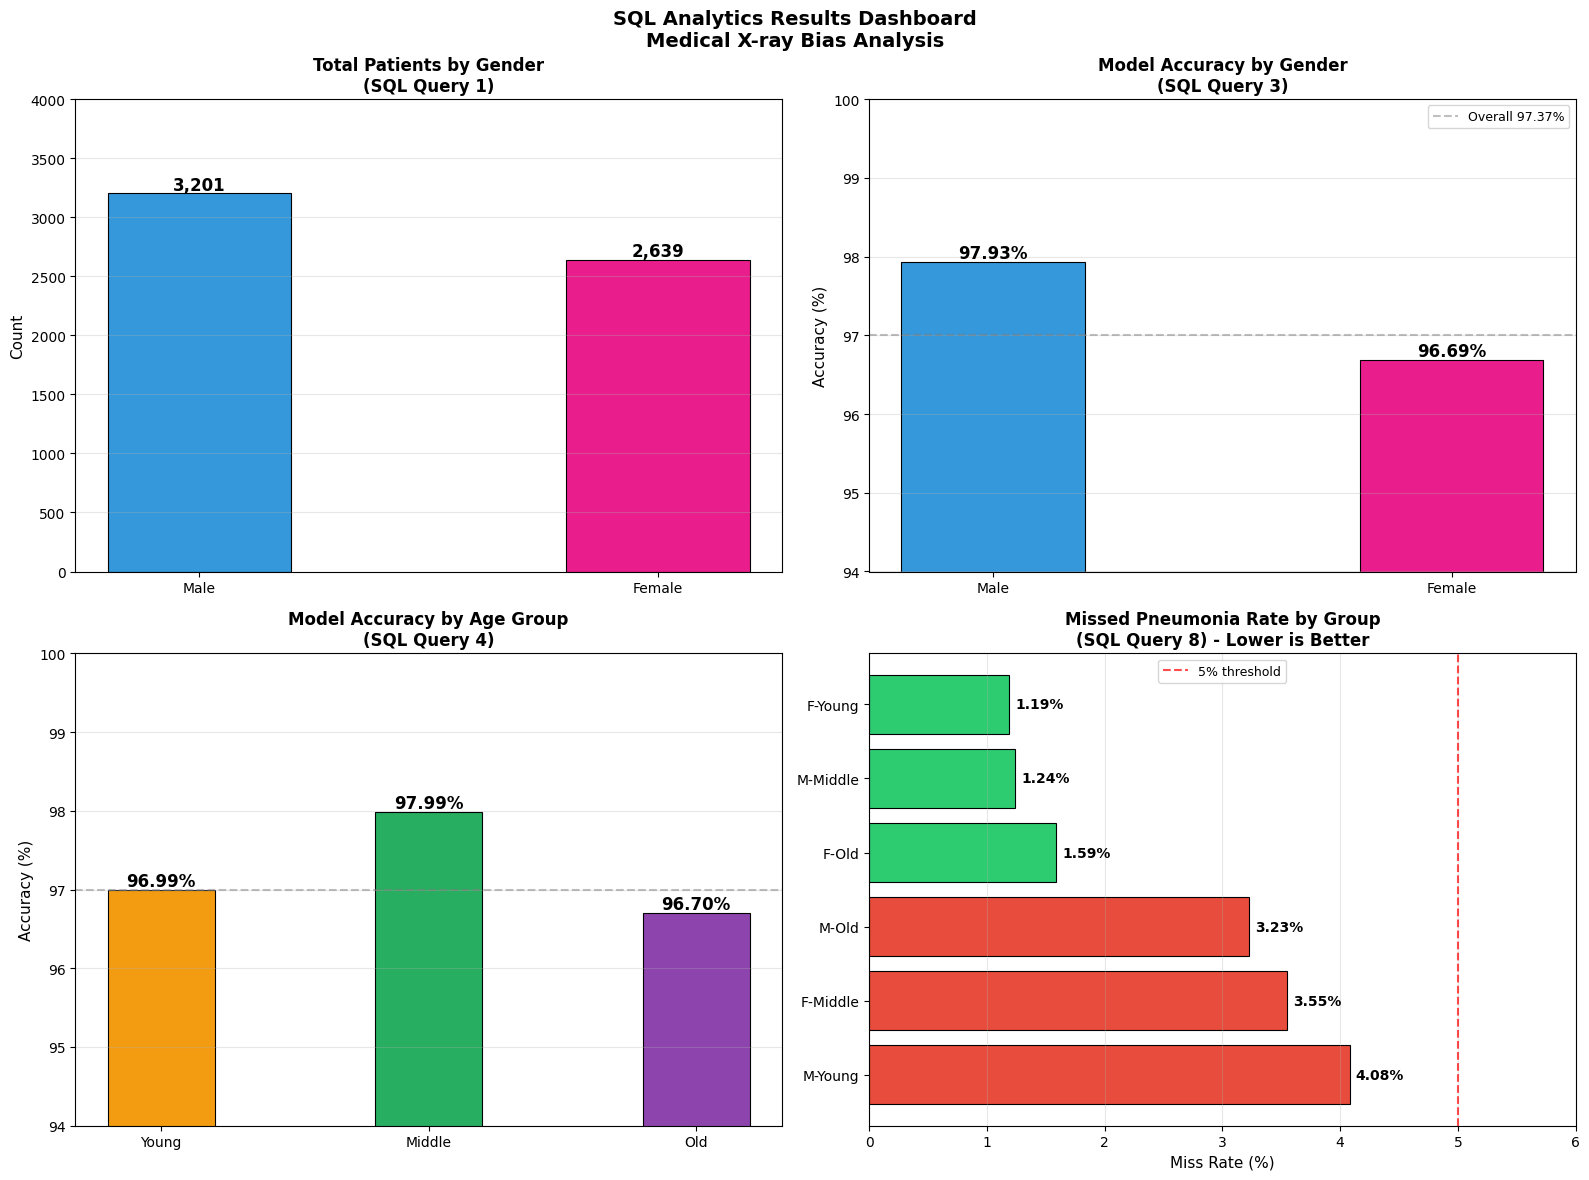

✅ SQL results dashboard saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/sql_results.png
✅ Cell 6 complete


In [7]:
# Cell 6: Visualize SQL query results

print("=" * 50)
print("   CELL 6: SQL RESULTS VISUALIZATION")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Chart 1: Patient count by gender ──────────────────
genders      = ['Male', 'Female']
total_counts = [3201, 2639]
colors_g     = ['#3498db', '#e91e8c']

bars1 = axes[0,0].bar(genders, total_counts,
                      color=colors_g,
                      edgecolor='black',
                      linewidth=0.8, width=0.4)
for bar, val in zip(bars1, total_counts):
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30,
        f'{val:,}', ha='center',
        fontsize=12, fontweight='bold')

axes[0,0].set_title(
    'Total Patients by Gender\n(SQL Query 1)',
    fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Count', fontsize=11)
axes[0,0].set_ylim(0, 4000)
axes[0,0].grid(axis='y', alpha=0.3)

# ── Chart 2: Accuracy by gender ───────────────────────
accuracies_g = [97.93, 96.69]

bars2 = axes[0,1].bar(genders, accuracies_g,
                      color=colors_g,
                      edgecolor='black',
                      linewidth=0.8, width=0.4)
for bar, val in zip(bars2, accuracies_g):
    axes[0,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'{val:.2f}%', ha='center',
        fontsize=12, fontweight='bold')

axes[0,1].set_title(
    'Model Accuracy by Gender\n(SQL Query 3)',
    fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Accuracy (%)', fontsize=11)
axes[0,1].set_ylim(94, 100)
axes[0,1].grid(axis='y', alpha=0.3)
axes[0,1].axhline(y=97, color='gray',
                  linestyle='--', alpha=0.5,
                  label='Overall 97.37%')
axes[0,1].legend(fontsize=9)

# ── Chart 3: Accuracy by age group ────────────────────
age_grps     = ['Young', 'Middle', 'Old']
accuracies_a = [96.99, 97.99, 96.70]
colors_a     = ['#f39c12', '#27ae60', '#8e44ad']

bars3 = axes[1,0].bar(age_grps, accuracies_a,
                      color=colors_a,
                      edgecolor='black',
                      linewidth=0.8, width=0.4)
for bar, val in zip(bars3, accuracies_a):
    axes[1,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f'{val:.2f}%', ha='center',
        fontsize=12, fontweight='bold')

axes[1,0].set_title(
    'Model Accuracy by Age Group\n(SQL Query 4)',
    fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Accuracy (%)', fontsize=11)
axes[1,0].set_ylim(94, 100)
axes[1,0].grid(axis='y', alpha=0.3)
axes[1,0].axhline(y=97, color='gray',
                  linestyle='--', alpha=0.5)

# ── Chart 4: Missed pneumonia by group ────────────────
groups    = ['M-Young', 'F-Middle', 'M-Old',
             'F-Old', 'M-Middle', 'F-Young']
miss_rate = [4.08, 3.55, 3.23, 1.59, 1.24, 1.19]
colors_m  = ['#e74c3c' if r > 3.0
             else '#e67e22' if r > 2.0
             else '#2ecc71'
             for r in miss_rate]

bars4 = axes[1,1].barh(groups, miss_rate,
                       color=colors_m,
                       edgecolor='black',
                       linewidth=0.8)
for bar, val in zip(bars4, miss_rate):
    axes[1,1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f}%', va='center',
        fontsize=10, fontweight='bold')

axes[1,1].set_title(
    'Missed Pneumonia Rate by Group\n'
    '(SQL Query 8) - Lower is Better',
    fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Miss Rate (%)', fontsize=11)
axes[1,1].set_xlim(0, 6)
axes[1,1].grid(axis='x', alpha=0.3)
axes[1,1].axvline(x=5.0, color='red',
                  linestyle='--', alpha=0.7,
                  label='5% threshold')
axes[1,1].legend(fontsize=9)

plt.suptitle(
    'SQL Analytics Results Dashboard\n'
    'Medical X-ray Bias Analysis',
    fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = f"{PLOTS}/sql_results.png"
plt.savefig(save_path, dpi=150,
            bbox_inches='tight')
plt.show()

print(f"✅ SQL results dashboard saved : {save_path}")
print("=" * 50)
print("✅ Cell 6 complete")

In [8]:
# Cell 7: Close database and print final summary

print("=" * 50)
print("   CELL 7: DATABASE SUMMARY & CLOSE")
print("=" * 50)

# ── Final row counts ───────────────────────────────────
print("   Final Database Contents:")
print(f"   {'Table':<18} {'Rows':>8} {'Columns'}")
print(f"   {'─'*18} {'─'*8} {'─'*20}")

table_info = {
    'patients'      : 'id,image,age,gender,split...',
    'predictions'   : 'id,image,true,pred,conf...',
    'bias_gender'   : 'id,gender,acc,prec,rec...',
    'bias_age_group': 'id,age_group,acc,prec...',
    'bias_combined' : 'id,gender,age_group,acc...',
}

total_rows = 0
for table, cols in table_info.items():
    count = cursor.execute(
        f"SELECT COUNT(*) FROM {table}"
    ).fetchone()[0]
    total_rows += count
    print(f"   {table:<18} {count:>8,} {cols}")

print(f"   {'─'*18} {'─'*8}")
print(f"   {'TOTAL':<18} {total_rows:>8,}")
print()

# ── Database file size ─────────────────────────────────
conn.commit()
db_size_kb = os.path.getsize(DB_PATH) / 1024
db_size_mb = db_size_kb / 1024
print(f"   Database file info:")
print(f"   Path    : {DB_PATH}")
print(f"   Size    : {db_size_kb:.1f} KB "
      f"({db_size_mb:.2f} MB)")
print()

# ── List all plots saved ───────────────────────────────
print(f"   All plots saved:")
plots_list = sorted(os.listdir(PLOTS))
for p in plots_list:
    size_kb = os.path.getsize(
        f"{PLOTS}/{p}") / 1024
    print(f"   ✅ {p:<40} {size_kb:.0f} KB")

print()

# ── List all results saved ─────────────────────────────
print(f"   All results saved:")
results_list = sorted(os.listdir(RESULTS))
for r in results_list:
    size_kb = os.path.getsize(
        f"{RESULTS}/{r}") / 1024
    print(f"   ✅ {r:<40} {size_kb:.0f} KB")

print()

# ── Close connection ───────────────────────────────────
conn.close()
print(f"✅ Database connection closed")
print()
print(f"   SQL Integration Complete!")
print(f"   5 tables created and populated")
print(f"   8 analytical queries executed")
print(f"   Dashboard visualization saved")
print("=" * 50)
print("✅ Cell 7 complete")

   CELL 7: DATABASE SUMMARY & CLOSE
   Final Database Contents:
   Table                  Rows Columns
   ────────────────── ──────── ────────────────────
   patients              5,840 id,image,age,gender,split...
   predictions             876 id,image,true,pred,conf...
   bias_gender               2 id,gender,acc,prec,rec...
   bias_age_group            3 id,age_group,acc,prec...
   bias_combined             6 id,gender,age_group,acc...
   ────────────────── ────────
   TOTAL                 6,727

   Database file info:
   Path    : D:/Projects/Harsh_Mini_Project/medical_xray_project/database/xray_metadata.db
   Size    : 564.0 KB (0.55 MB)

   All plots saved:
   ✅ bias_age_groups.png                      150 KB
   ✅ bias_combined_heatmap.png                120 KB
   ✅ bias_gender.png                          115 KB
   ✅ class_distribution.png                   93 KB
   ✅ confusion_matrix.png                     89 KB
   ✅ demographic_distribution.png             123 KB
   ✅ model